# TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
**Nhiệm vụ của phần này:**
1. **Kiểm tra dataset:** Đếm xem số lượng ảnh các loại quần áo có đều nhau không.
2. **Chia tập Train và Test:** Chia dữ liệu theo tỷ lệ chuẩn 60/20/20 và giữ đều tỉ lệ các lớp (Stratified Sampling).
3. **Data Augmentation:** Xoay/lật ảnh ngẫu nhiên (Data Augmentation) để AI học được nhiều góc độ thực tế.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

# Khởi tạo danh sách tên các nhãn để trực quan hóa
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Bước 1: Tải dữ liệu & Kiểm tra xem có bị "học lệch" không (Data Analysis)

* **Ý nghĩa:** Tải bộ ảnh quần áo `FashionMNIST` dùng PyTorch về và vẽ biểu đồ đếm xem mỗi loại (áo, quần, váy, giày...) có bao nhiêu ảnh.
* **Mục tiêu:** Đảm bảo dữ liệu cân bằng. Nếu một loại có quá nhiều ảnh (ví dụ 10,000 ảnh áo) mà loại khác quá ít (chỉ 100 ảnh váy), AI học xong sẽ bị "thiên vị" và luôn đoán bừa là áo.

In [2]:
# Tải dữ liệu thô (chỉ chuyển thành Tensor để phân tích)
raw_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
raw_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]


In [3]:
img, label = raw_train[0]

Tổng số mẫu tập Train gốc: 60000 mẫu
Kích thước mỗi ảnh: torch.Size([1, 28, 28])


/tmp/ipykernel_5306/939405042.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, palette="viridis")


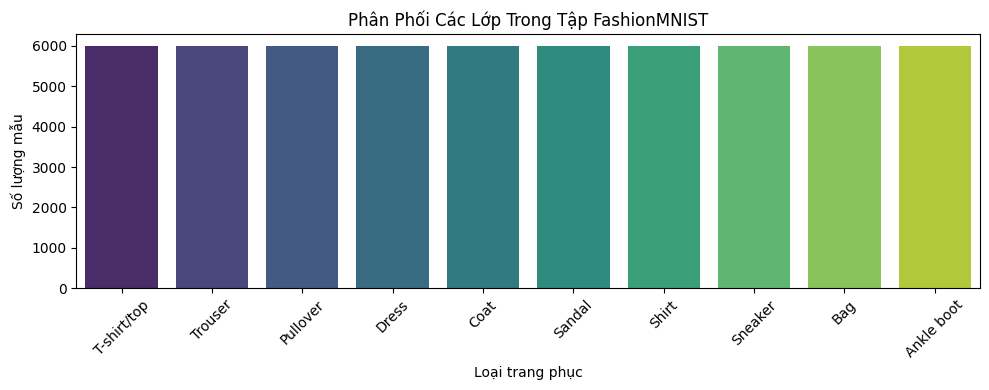

In [4]:

# Gộp nhãn để kiểm tra phân phối tổng thể
train_labels = raw_train.targets.numpy()
print(f"Tổng số mẫu tập Train gốc: {len(train_labels)} mẫu")
print(f"Kích thước mỗi ảnh: {raw_train[0][0].shape}")

# Vẽ biểu đồ phân phối tần suất các lớp
plt.figure(figsize=(10, 4))
sns.countplot(x=train_labels, palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Phân Phối Các Lớp Trong Tập FashionMNIST")
plt.xlabel("Loại trang phục")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()

Tổng số mẫu tập Train gốc: 10000 mẫu
Kích thước mỗi ảnh: torch.Size([1, 28, 28])


/tmp/ipykernel_5306/950204112.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_labels, palette="viridis")


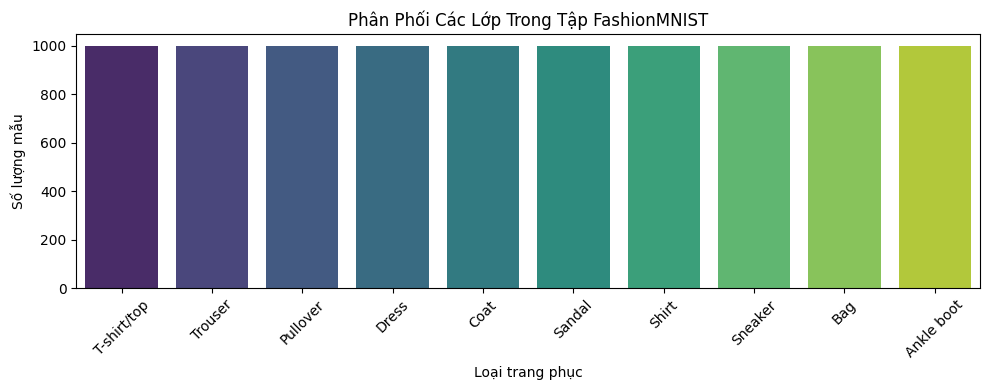

In [5]:

# Gộp nhãn để kiểm tra phân phối tổng thể
test_labels = raw_test.targets.numpy()
print(f"Tổng số mẫu tập Train gốc: {len(test_labels)} mẫu")
print(f"Kích thước mỗi ảnh: {raw_test[0][0].shape}")

# Vẽ biểu đồ phân phối tần suất các lớp
plt.figure(figsize=(10, 4))
sns.countplot(x=test_labels, palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Phân Phối Các Lớp Trong Tập FashionMNIST")
plt.xlabel("Loại trang phục")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()

## Bước 2: Chia tập dữ liệu 60/20/20 (Stratified Sampling)

* **Vấn đề:** Bộ dữ liệu mặc định chỉ chia sẵn thành 2 tập (Train 60k và Test 10k). Chúng ta bị thiếu tập **Validation** (tập dùng để "nếm thử" xem AI học có bị học vẹt - Overfitting hay không).
* **Giải pháp:**
 1. Gộp toàn bộ dữ liệu lại thành 70,000 ảnh để xáo trộn ngẫu nhiên.
  2. Cắt lần 1: Trích ra 20% làm tập **Test** .
  3. Cắt lần 2: Lấy phần còn lại chia thành tập **Train** (60%) và **Validation** (20%).
* **Từ khóa "Stratified":** Đảm bảo dù có chia nhỏ ra thì tỉ lệ các loại quần áo trong mỗi tập con vẫn bằng chằn chặn nhau, không bị lệch pha.

In [6]:
# Gộp toàn bộ dữ liệu 70,000 mẫu
full_dataset = ConcatDataset([raw_train, raw_test])
all_labels = np.concatenate([raw_train.targets.numpy(), raw_test.targets.numpy()])
all_indices = np.arange(len(full_dataset))

# Lần cắt 1: Trích ra đúng 20% làm tập Test (14,000 mẫu)
temp_indices, test_indices, y_temp, y_test = train_test_split(
    all_indices, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# Lần cắt 2: Cắt tập Temp thành Train (60% ~ 42,000 mẫu) và Validation (20% ~ 14,000 mẫu)
train_indices, val_indices, _, _ = train_test_split(
    temp_indices, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("--- Kết quả phân chia dữ liệu ---")
print(f"Số lượng mẫu tập Train (60%):      {len(train_indices)} mẫu")
print(f"Số lượng mẫu tập Validation (20%): {len(val_indices)} mẫu")
print(f"Số lượng mẫu tập Test (20%):       {len(test_indices)} mẫu")

--- Kết quả phân chia dữ liệu ---
Số lượng mẫu tập Train (60%):      42000 mẫu
Số lượng mẫu tập Validation (20%): 14000 mẫu
Số lượng mẫu tập Test (20%):       14000 mẫu


## Bước 3: Tăng cường hình ảnh (Data Augmentation) & Đóng gói dữ liệu (DataLoader)

* **Tăng cường dữ liệu (Data Augmentation):** Làm phong phú tập **Train** bằng cách xoay nhẹ ảnh hoặc lật ngang ngẫu nhiên. Giúp AI làm quen với nhiều góc chụp. *Lưu ý tinh tế:* Tuyệt đối không lật dọc ảnh quần áo vì thực tế không ai mặc đồ lộn ngược đầu xuống đất.
* **Tập Validation & Test:** Giữ nguyên ảnh gốc (chỉ thu nhỏ pixel về khoảng `[-1, 1]`) để chấm điểm AI khách quan.
* **DataLoader:** Đóng gói ảnh thành từng nhóm nhỏ (Batch size = 64) để nạp dần vào mạng CNN, giúp máy tính không bị "sập" do quá tải bộ nhớ.

In [7]:
# Định nghĩa các bộ lọc biến đổi dữ liệu
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

raw_train_aug = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_transform)
raw_test_aug = datasets.FashionMNIST(root="./data", train=False, download=True, transform=train_transform)
full_train_dataset = ConcatDataset([raw_train_aug, raw_test_aug])

raw_train_eval = datasets.FashionMNIST(root="./data", train=True, download=True, transform=eval_transform)
raw_test_eval = datasets.FashionMNIST(root="./data", train=False, download=True, transform=eval_transform)
full_eval_dataset = ConcatDataset([raw_train_eval, raw_test_eval])

# Bọc các tập dữ liệu đã chia bằng các phép biến đổi tương ứng
# Dùng các index (0-69999) để trích xuất từ tập full (70k ảnh)
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_eval_dataset, val_indices)
test_dataset = Subset(full_eval_dataset, test_indices)

# Khởi tạo DataLoader sẵn sàng nạp vào mạng CNN để huấn luyện
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("--- HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU SẴN SÀNG CHO VÒNG LẶP HUẤN LUYỆN ---")

--- HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU SẴN SÀNG CHO VÒNG LẶP HUẤN LUYỆN ---


# PHẦN II: XÂY DỰNG VÀ SO SÁNH MODEL CNN 2D VÀ CNN 1D
**Nhiệm vụ của phần này:**
1. **Triển khai model CNN 2D:** Theo đúng cấu trúc yêu cầu từ đề bài.
2. **Thiết kế model CNN 1D tương ứng:** Làm phẳng ảnh và xử lý qua Conv1D.
3. **Huấn luyện và Đánh giá:** Chạy huấn luyện cả 2 model trên tập dữ liệu FashionMNIST và so sánh Loss, Accuracy, thời gian huấn luyện và số lượng tham số.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN2D(nn.Module):
    def __init__(self):
        super(CNN2D, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Khởi tạo model và in số lượng tham số
model_2d = CNN2D()
total_params_2d = sum(p.numel() for p in model_2d.parameters() if p.requires_grad)
print(model_2d)
print(f"Tổng số tham số trainable của CNN 2D: {total_params_2d:,}")

CNN2D(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start

In [9]:
class CNN2D_Simple(nn.Module):
    def __init__(self):
        super(CNN2D_Simple, self).__init__()

        # Block 1 (chỉ có 1 lớp Conv2d)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Block 2 (chỉ có 1 lớp Conv2d)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Khởi tạo model và in số lượng tham số
model_2d_simple = CNN2D_Simple()
total_params_2d_simple = sum(p.numel() for p in model_2d_simple.parameters() if p.requires_grad)
print(model_2d_simple)
print(f"Tổng số tham số trainable của CNN 2D Simple (2 lớp Conv): {total_params_2d_simple:,}")

CNN2D_Simple(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Tổng số tham số trainable của CNN 2D Simple (2 lớp Conv): 421,834


In [10]:
class CNN1D(nn.Module):
    def __init__(self):
        super(CNN1D, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 196, 128), # 784 -> 392 (maxpool 1) -> 196 (maxpool 2)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        # Biến đổi x từ (B, 1, 28, 28) thành (B, 1, 784) để xử lý dạng 1D sequence
        x = x.view(x.size(0), 1, -1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model_1d = CNN1D()
total_params_1d = sum(p.numel() for p in model_1d.parameters() if p.requires_grad)
print(model_1d)
print(f"Tổng số tham số trainable của CNN 1D: {total_params_1d:,}")

CNN1D(
  (block1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    

In [11]:
import time

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

def fit_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    start_time = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    total_time = time.time() - start_time
    print(f"Hoàn thành huấn luyện trong {total_time:.2f}s\n")
    return history, total_time

In [12]:
print("--- HUẤN LUYỆN MODEL CNN 2D ---")
model_2d = CNN2D()
history_2d, time_2d = fit_model(model_2d, train_loader, valid_loader, epochs=10, lr=0.001)

# Đánh giá trên tập Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss_2d, test_acc_2d = evaluate(model_2d.to(device), test_loader, nn.CrossEntropyLoss(), device)
print(f"=> CNN 2D Test Loss: {test_loss_2d:.4f}, Test Accuracy: {test_acc_2d*100:.2f}%")

--- HUẤN LUYỆN MODEL CNN 2D ---
Training on device: cuda
Epoch [1/10] - Train Loss: 0.6262, Train Acc: 77.52% | Val Loss: 0.3511, Val Acc: 87.04%
Epoch [2/10] - Train Loss: 0.4322, Train Acc: 84.58% | Val Loss: 0.3043, Val Acc: 88.69%
Epoch [3/10] - Train Loss: 0.3817, Train Acc: 86.31% | Val Loss: 0.2663, Val Acc: 90.13%
Epoch [4/10] - Train Loss: 0.3467, Train Acc: 87.71% | Val Loss: 0.2789, Val Acc: 89.36%
Epoch [5/10] - Train Loss: 0.3331, Train Acc: 88.10% | Val Loss: 0.2582, Val Acc: 90.13%
Epoch [6/10] - Train Loss: 0.3155, Train Acc: 88.96% | Val Loss: 0.2447, Val Acc: 91.26%
Epoch [7/10] - Train Loss: 0.2973, Train Acc: 89.55% | Val Loss: 0.2499, Val Acc: 90.60%
Epoch [8/10] - Train Loss: 0.2843, Train Acc: 89.76% | Val Loss: 0.2318, Val Acc: 91.60%
Epoch [9/10] - Train Loss: 0.2796, Train Acc: 90.02% | Val Loss: 0.2189, Val Acc: 92.08%
Epoch [10/10] - Train Loss: 0.2692, Train Acc: 90.41% | Val Loss: 0.2312, Val Acc: 91.83%
Hoàn thành huấn luyện trong 223.95s

=> CNN 2D Test 

In [13]:
print("--- HUẤN LUYỆN MODEL CNN 2D SIMPLE (2 LỚP CONV) ---")
model_2d_simple = CNN2D_Simple()
history_2d_simple, time_2d_simple = fit_model(model_2d_simple, train_loader, valid_loader, epochs=10, lr=0.001)

# Đánh giá trên tập Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss_2d_simple, test_acc_2d_simple = evaluate(model_2d_simple.to(device), test_loader, nn.CrossEntropyLoss(), device)
print(f"=> CNN 2D Simple Test Loss: {test_loss_2d_simple:.4f}, Test Accuracy: {test_acc_2d_simple*100:.2f}%")

--- HUẤN LUYỆN MODEL CNN 2D SIMPLE (2 LỚP CONV) ---
Training on device: cuda
Epoch [1/10] - Train Loss: 0.6540, Train Acc: 76.34% | Val Loss: 0.3915, Val Acc: 85.81%
Epoch [2/10] - Train Loss: 0.4831, Train Acc: 82.55% | Val Loss: 0.3421, Val Acc: 87.27%
Epoch [3/10] - Train Loss: 0.4353, Train Acc: 84.27% | Val Loss: 0.2979, Val Acc: 88.64%
Epoch [4/10] - Train Loss: 0.3985, Train Acc: 85.44% | Val Loss: 0.2984, Val Acc: 88.93%
Epoch [5/10] - Train Loss: 0.3790, Train Acc: 86.26% | Val Loss: 0.2941, Val Acc: 88.98%
Epoch [6/10] - Train Loss: 0.3675, Train Acc: 86.94% | Val Loss: 0.2732, Val Acc: 89.99%
Epoch [7/10] - Train Loss: 0.3487, Train Acc: 87.52% | Val Loss: 0.2761, Val Acc: 89.99%
Epoch [8/10] - Train Loss: 0.3379, Train Acc: 87.84% | Val Loss: 0.2670, Val Acc: 90.16%
Epoch [9/10] - Train Loss: 0.3250, Train Acc: 88.20% | Val Loss: 0.2597, Val Acc: 90.58%
Epoch [10/10] - Train Loss: 0.3205, Train Acc: 88.34% | Val Loss: 0.2661, Val Acc: 90.39%
Hoàn thành huấn luyện trong 196.

In [14]:
print("--- HUẤN LUYỆN MODEL CNN 1D ---")
model_1d = CNN1D()
history_1d, time_1d = fit_model(model_1d, train_loader, valid_loader, epochs=10, lr=0.001)

# Đánh giá trên tập Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss_1d, test_acc_1d = evaluate(model_1d.to(device), test_loader, nn.CrossEntropyLoss(), device)
print(f"=> CNN 1D Test Loss: {test_loss_1d:.4f}, Test Accuracy: {test_acc_1d*100:.2f}%")

--- HUẤN LUYỆN MODEL CNN 1D ---
Training on device: cuda
Epoch [1/10] - Train Loss: 0.7173, Train Acc: 73.85% | Val Loss: 0.3759, Val Acc: 86.19%
Epoch [2/10] - Train Loss: 0.5238, Train Acc: 80.95% | Val Loss: 0.3401, Val Acc: 87.61%
Epoch [3/10] - Train Loss: 0.4733, Train Acc: 82.89% | Val Loss: 0.3022, Val Acc: 88.84%
Epoch [4/10] - Train Loss: 0.4456, Train Acc: 83.73% | Val Loss: 0.2901, Val Acc: 89.46%
Epoch [5/10] - Train Loss: 0.4241, Train Acc: 84.79% | Val Loss: 0.2744, Val Acc: 89.80%
Epoch [6/10] - Train Loss: 0.4029, Train Acc: 85.56% | Val Loss: 0.2698, Val Acc: 90.27%
Epoch [7/10] - Train Loss: 0.3925, Train Acc: 85.94% | Val Loss: 0.2620, Val Acc: 90.41%
Epoch [8/10] - Train Loss: 0.3769, Train Acc: 86.49% | Val Loss: 0.2534, Val Acc: 90.71%
Epoch [9/10] - Train Loss: 0.3670, Train Acc: 86.90% | Val Loss: 0.2544, Val Acc: 90.81%
Epoch [10/10] - Train Loss: 0.3531, Train Acc: 87.25% | Val Loss: 0.2472, Val Acc: 90.98%
Hoàn thành huấn luyện trong 225.76s

=> CNN 1D Test 

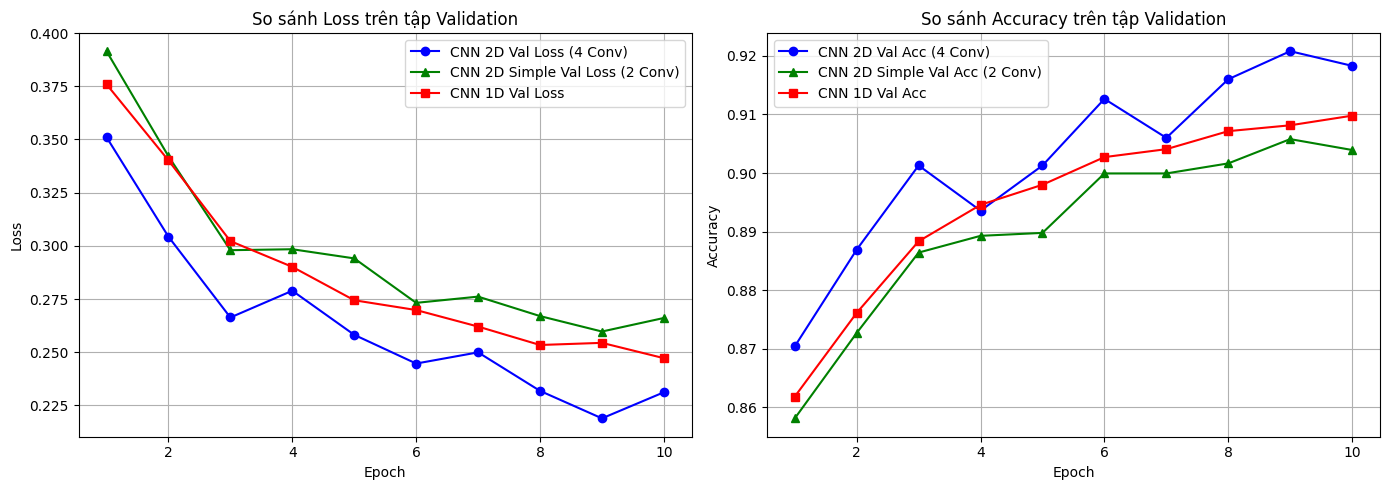

Thông số so sánh               | CNN 2D (4 Conv)    | CNN 2D (2 Conv)    | CNN 1D         
Trainable Parameters           | 468,202            | 421,834            | 1,629,226      
Thời gian train (10 epochs)    | 223.95s            | 196.96s            | 225.76s        
Validation Accuracy tốt nhất   | 92.08%             | 90.58%             | 90.98%         
Test Accuracy                  | 91.36%             | 90.22%             | 90.47%         


In [15]:
# So sánh và trực quan hóa kết quả cho cả 3 model
epochs_range = range(1, 11)

plt.figure(figsize=(14, 5))

# Biểu đồ Loss trên tập Validation
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_2d['val_loss'], 'b-o', label='CNN 2D Val Loss (4 Conv)')
plt.plot(epochs_range, history_2d_simple['val_loss'], 'g-^', label='CNN 2D Simple Val Loss (2 Conv)')
plt.plot(epochs_range, history_1d['val_loss'], 'r-s', label='CNN 1D Val Loss')
plt.title('So sánh Loss trên tập Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy trên tập Validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_2d['val_acc'], 'b-o', label='CNN 2D Val Acc (4 Conv)')
plt.plot(epochs_range, history_2d_simple['val_acc'], 'g-^', label='CNN 2D Simple Val Acc (2 Conv)')
plt.plot(epochs_range, history_1d['val_acc'], 'r-s', label='CNN 1D Val Acc')
plt.title('So sánh Accuracy trên tập Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# In bảng so sánh
print("="*95)
print(f"{'Thông số so sánh':<30} | {'CNN 2D (4 Conv)':<18} | {'CNN 2D (2 Conv)':<18} | {'CNN 1D':<15}")
print("="*95)
print(f"{'Trainable Parameters':<30} | {total_params_2d:<18,} | {total_params_2d_simple:<18,} | {total_params_1d:<15,}")
print(f"{'Thời gian train (10 epochs)':<30} | {f'{time_2d:.2f}s':<18} | {f'{time_2d_simple:.2f}s':<18} | {f'{time_1d:.2f}s':<15}")
print(f"{'Validation Accuracy tốt nhất':<30} | {f'{max(history_2d["val_acc"])*100:.2f}%':<18} | {f'{max(history_2d_simple["val_acc"])*100:.2f}%':<18} | {f'{max(history_1d["val_acc"])*100:.2f}%':<15}")
print(f"{'Test Accuracy':<30} | {f'{test_acc_2d*100:.2f}%':<18} | {f'{test_acc_2d_simple*100:.2f}%':<18} | {f'{test_acc_1d*100:.2f}%':<15}")
print("="*95)

# PHẦN III: ĐÁNH GIÁ CHI TIẾT MODEL TỐT NHẤT (MODEL EVALUATION)
**Nhiệm vụ của phần này:** Soi kỹ model chiến thắng ở Phần II để hiểu nó mạnh/yếu ở đâu.
1. **Biểu đồ Loss & Accuracy:** Vẽ đường Train vs Validation qua từng epoch để kiểm tra hiện tượng học vẹt (Overfitting).
2. **Confusion Matrix:** Ma trận nhầm lẫn cho biết model hay nhầm loại quần áo nào với loại nào.
3. **Classification Report:** Bảng Precision / Recall / F1-score cho từng lớp.
4. **Ảnh bị nhận diện nhầm:** Trực quan hóa các ca model đoán sai để hiểu lý do.

## Bước 1: Chọn model tốt nhất
Tự động chọn model có **Test Accuracy** cao nhất trong 3 model đã huấn luyện ở Phần II làm đối tượng đánh giá.

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Gom 3 model lai. CHON model tot nhat dua tren VALIDATION Accuracy.
# KHONG dung Test Accuracy de chon model -> tranh ro ri du lieu (data leakage).
# Tap Test chi duoc dung mot lan duy nhat de bao cao ket qua cuoi cung.
results = {
    'CNN 2D (4 Conv)':  (model_2d,        history_2d,        test_acc_2d),
    'CNN 2D (2 Conv)':  (model_2d_simple, history_2d_simple, test_acc_2d_simple),
    'CNN 1D':           (model_1d,        history_1d,        test_acc_1d),
}
best_name = max(results, key=lambda k: max(results[k][1]['val_acc']))
best_model, best_history, best_test_acc = results[best_name]
best_model = best_model.to(device)

print(f"Model tot nhat (chon theo Validation Accuracy): {best_name}")
print(f"Best Validation Accuracy: {max(best_history['val_acc'])*100:.2f}%")
print(f"Test Accuracy (bao cao 1 lan, khong dung de chon model): {best_test_acc*100:.2f}%")

Model tot nhat (chon theo Validation Accuracy): CNN 2D (4 Conv)
Best Validation Accuracy: 92.08%
Test Accuracy (bao cao 1 lan, khong dung de chon model): 91.36%


## Bước 2: Biểu đồ Loss & Accuracy (Train vs Validation)
* **Mục tiêu:** So sánh đường Train và Validation. Nếu Train Loss giảm sâu nhưng Validation Loss lại đi lên (2 đường tách xa nhau) thì model đang **học vẹt (Overfitting)**.
* Hai đường bám sát nhau = model học tốt và tổng quát hóa ổn.

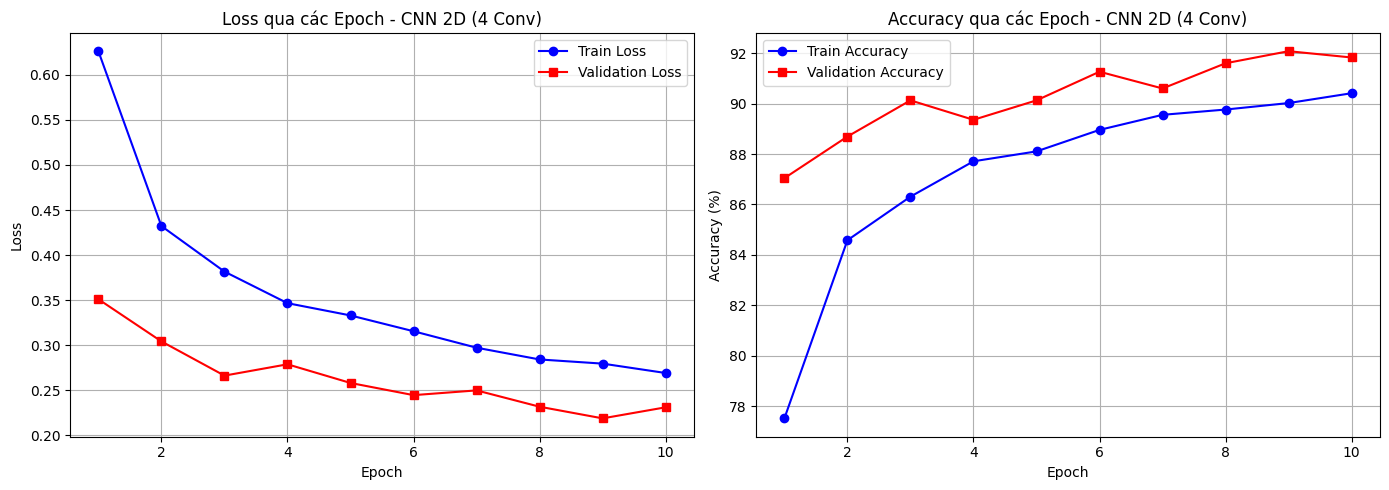

In [17]:
epochs_range = range(1, len(best_history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, best_history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, best_history['val_loss'], 'r-s', label='Validation Loss')
plt.title(f'Loss qua các Epoch - {best_name}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a*100 for a in best_history['train_acc']], 'b-o', label='Train Accuracy')
plt.plot(epochs_range, [a*100 for a in best_history['val_acc']], 'r-s', label='Validation Accuracy')
plt.title(f'Accuracy qua các Epoch - {best_name}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Bước 3: Thu thập toàn bộ dự đoán trên tập Test
Cho model dự đoán toàn bộ 14,000 ảnh tập Test, lưu lại: nhãn dự đoán, nhãn thật và ảnh gốc để phục vụ vẽ Confusion Matrix và soi ảnh sai.

In [18]:
def get_all_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_labels, all_images = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            _, preds = outputs.max(1)
            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_images.append(images.cpu())
    return torch.cat(all_preds), torch.cat(all_labels), torch.cat(all_images)

y_pred, y_true, test_images = get_all_predictions(best_model, test_loader, device)
print(f"Đã dự đoán xong {len(y_pred)} ảnh trong tập Test.")

Đã dự đoán xong 14000 ảnh trong tập Test.


## Bước 4: Confusion Matrix (Ma trận nhầm lẫn)
* **Cách đọc:** Hàng = nhãn **thật**, Cột = nhãn **dự đoán**.
* Đường chéo chính = số ảnh đoán đúng (càng đậm càng tốt).
* Ô nằm ngoài đường chéo = số ảnh bị nhầm. Ví dụ ô [Shirt, T-shirt] lớn nghĩa là model hay nhầm Áo sơ mi thành Áo phông.

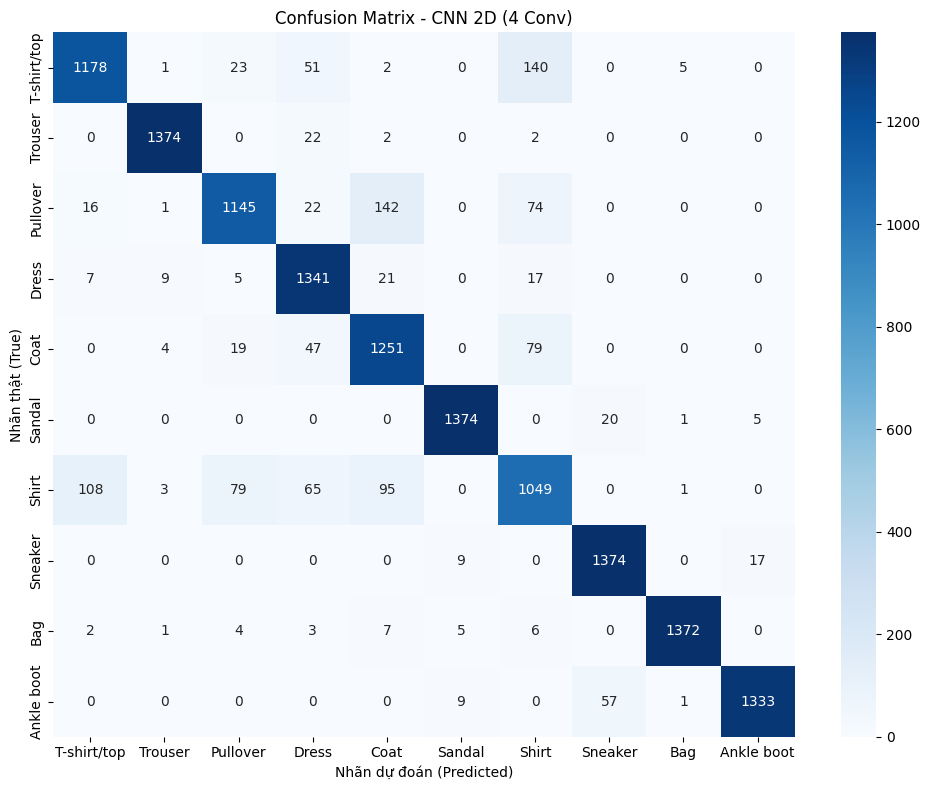

In [19]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Nhãn dự đoán (Predicted)')
plt.ylabel('Nhãn thật (True)')
plt.tight_layout()
plt.show()

## Bước 5: Classification Report
Bảng chi tiết cho từng lớp:
* **Precision:** Trong các ảnh model đoán là lớp X, bao nhiêu % đúng.
* **Recall:** Trong các ảnh thực sự là lớp X, model bắt được bao nhiêu %.
* **F1-score:** Trung bình điều hòa của Precision và Recall (điểm tổng hợp).

In [20]:
print(f"Báo cáo phân loại chi tiết - {best_name}\n")
print(classification_report(y_true.numpy(), y_pred.numpy(),
                            target_names=class_names, digits=4))

Báo cáo phân loại chi tiết - CNN 2D (4 Conv)

              precision    recall  f1-score   support

 T-shirt/top     0.8986    0.8414    0.8691      1400
     Trouser     0.9864    0.9814    0.9839      1400
    Pullover     0.8980    0.8179    0.8561      1400
       Dress     0.8646    0.9579    0.9088      1400
        Coat     0.8230    0.8936    0.8568      1400
      Sandal     0.9835    0.9814    0.9825      1400
       Shirt     0.7674    0.7493    0.7582      1400
     Sneaker     0.9469    0.9814    0.9639      1400
         Bag     0.9942    0.9800    0.9871      1400
  Ankle boot     0.9838    0.9521    0.9677      1400

    accuracy                         0.9136     14000
   macro avg     0.9146    0.9136    0.9134     14000
weighted avg     0.9146    0.9136    0.9134     14000



## Bước 6: Các ảnh bị nhận diện nhầm
Hiển thị 25 ảnh model đoán sai. Tiêu đề mỗi ảnh ghi **nhãn thật** và **nhãn model đoán** (màu đỏ) để thấy model nhầm vì sao (thường do các loại quần áo nhìn giống nhau).

Tổng số ảnh bị nhận diện nhầm: 1209 / 14000 (8.64%)


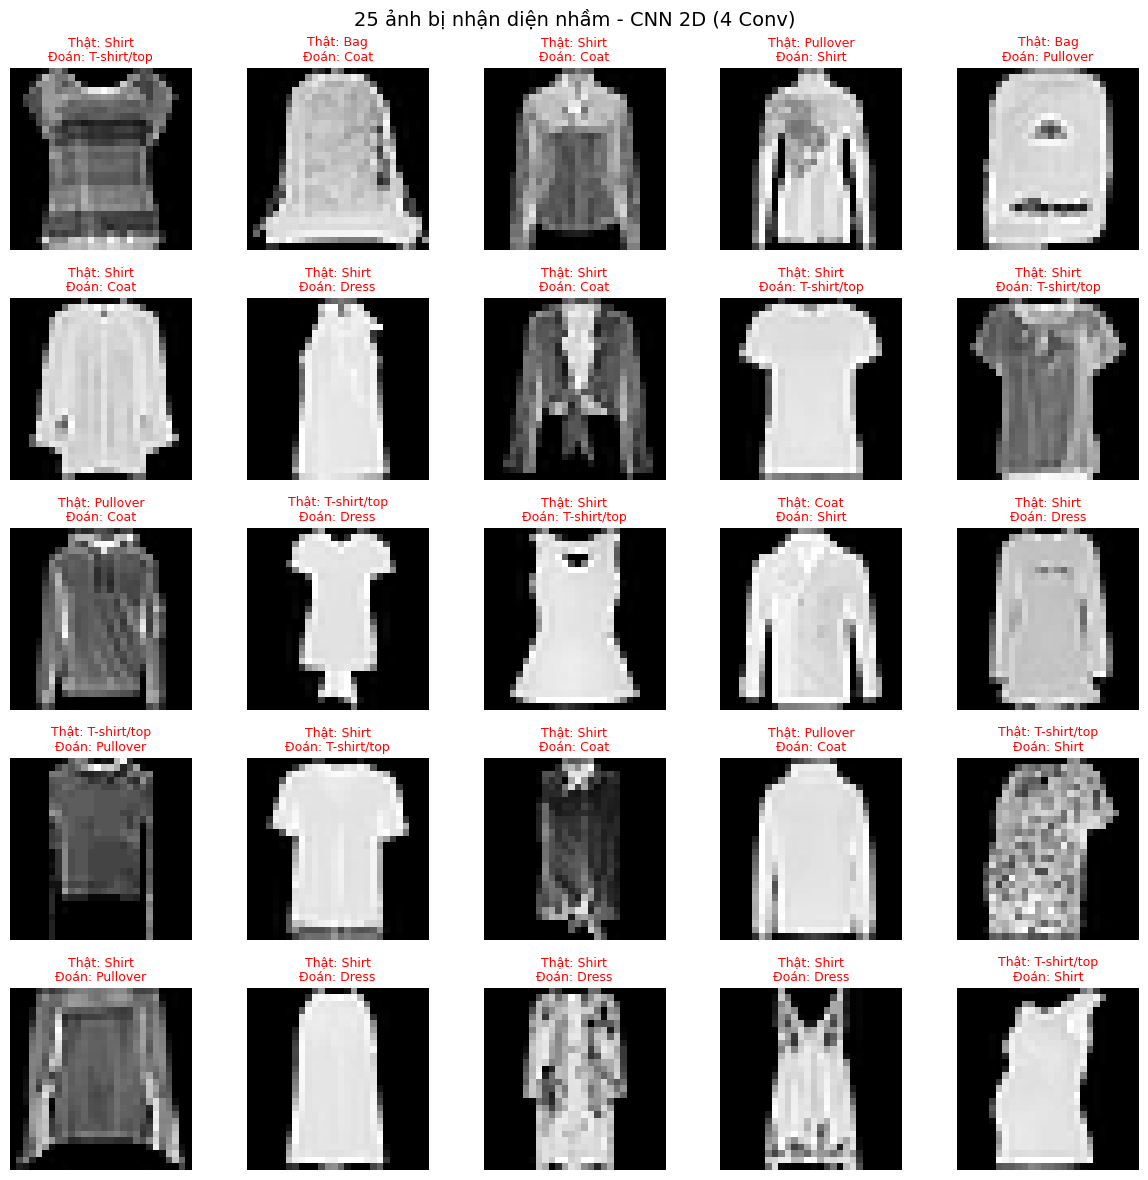

In [21]:
# Tìm vị trí các ảnh bị nhận diện nhầm
wrong_idx = (y_pred != y_true).nonzero(as_tuple=True)[0]
print(f"Tổng số ảnh bị nhận diện nhầm: {len(wrong_idx)} / {len(y_true)} "
      f"({len(wrong_idx)/len(y_true)*100:.2f}%)")

n_show = min(25, len(wrong_idx))
plt.figure(figsize=(12, 12))
for i in range(n_show):
    idx = wrong_idx[i].item()
    img = test_images[idx].squeeze() * 0.5 + 0.5  # bỏ chuẩn hóa [-1,1] -> [0,1]
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Thật: {class_names[y_true[idx]]}\nĐoán: {class_names[y_pred[idx]]}",
              color='red', fontsize=9)
plt.suptitle(f'25 ảnh bị nhận diện nhầm - {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

## Bước 7: Top các cặp lớp bị nhầm nhiều nhất
Liệt kê những cặp (Thật -> Đoán) bị nhầm nhiều nhất, giúp tổng kết điểm yếu chính của model.

In [22]:
# Lấy các giá trị ngoài đường chéo của confusion matrix
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = [(cm_off[i, j], class_names[i], class_names[j])
         for i in range(len(class_names))
         for j in range(len(class_names))
         if cm_off[i, j] > 0]
pairs.sort(reverse=True)

print("Top 10 cặp bị nhầm lẫn nhiều nhất (Nhãn thật -> Nhãn đoán):")
for count, t, p in pairs[:10]:
    print(f"  {t:<12} -> {p:<12}: {count} ảnh")

Top 10 cặp bị nhầm lẫn nhiều nhất (Nhãn thật -> Nhãn đoán):
  Pullover     -> Coat        : 142 ảnh
  T-shirt/top  -> Shirt       : 140 ảnh
  Shirt        -> T-shirt/top : 108 ảnh
  Shirt        -> Coat        : 95 ảnh
  Shirt        -> Pullover    : 79 ảnh
  Coat         -> Shirt       : 79 ảnh
  Pullover     -> Shirt       : 74 ảnh
  Shirt        -> Dress       : 65 ảnh
  Ankle boot   -> Sneaker     : 57 ảnh
  T-shirt/top  -> Dress       : 51 ảnh


In [ ]:
# Luu model nen (baseline) de tai su dung o s5 -> khoi huan luyen lai (chay nhanh hon).
import os
os.makedirs("models", exist_ok=True)
torch.save(best_model.state_dict(), "models/s3_baseline_cnn2d.pth")
print("Da luu baseline cua s3 vao: models/s3_baseline_cnn2d.pth")